In [1]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace
from omegaconf import DictConfig, OmegaConf
from typing import Any
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preprocess the files 

In [2]:
def get_model(filename: str):
    cfg = OmegaConf.create({'load_model': filename})
    model_path, run_cfg = _load_run(cfg)
    with open(model_path, "rb") as f:
        saved = pickle.load(f)
    model = saved["model"]
    feature_cols = saved["feature_cols"]
    feat_params = SimpleNamespace(**saved["feat_params"])
    return model, feature_cols, feat_params, run_cfg

In [3]:
def build_data(run_cfg: DictConfig, feat_params: Any):
    pothole_df, weather_df = build_daily(run_cfg)
    feat_df = assemble_features(pothole_df, weather_df,feat_params)
    feat_df = make_split(feat_df, run_cfg.split)
    return feat_df

In [4]:
def get_results(f: str): 
    model, feature_cols, feat_params, run_cfg = get_model(f)
    print(f"Feature params: {feat_params}")
    feat_df = build_data(run_cfg, feat_params)

    # get test data
    test_df = feat_df[feat_df["split"] == "test"]
    X_test = test_df[feature_cols]
    y_test = test_df["Y"]

    # get predictions
    y_test_preds = model.predict(X_test, recursive = True)

    return y_test, y_test_preds, test_df, model

# Plot over the models 

Feature params: namespace(d=1, d_f=21, d_p=8, d_s=14, k_AR=10, l_f=10, l_p=9, l_s=10)
[assemble_features] kept 1815/1826 rows (99.4%) after dropping NaNs
Using recursive prediction with k_AR = {k_AR}
Feature params: namespace(d=5, d_f=9, d_p=15, d_s=20, k_AR=0, l_f=8, l_p=10, l_s=10)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=21, d_p=8, d_s=8, k_AR=8, l_f=1, l_p=9, l_s=7)
[assemble_features] kept 1817/1826 rows (99.5%) after dropping NaNs
Using recursive prediction with k_AR = {k_AR}
Feature params: namespace(d=5, d_f=8, d_p=21, d_s=7, k_AR=0, l_f=9, l_p=10, l_s=1)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=5, d_f=8, d_p=7, d_s=9, k_AR=0, l_f=10, l_p=9, l_s=5)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs

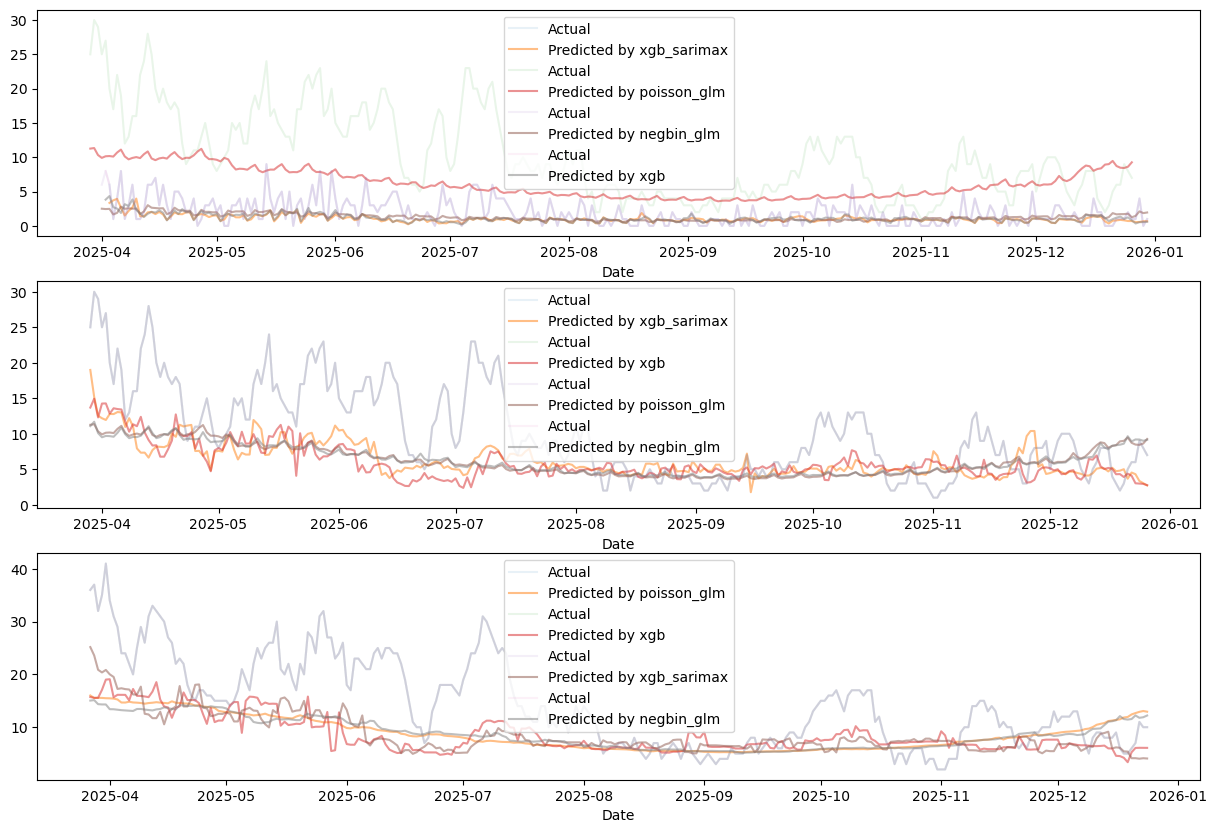

In [5]:
fig = plt.figure(figsize=(15, 10))
ax = fig.subplots(3, 1)
for i, d in enumerate([1, 5, 7]):
    results = os.listdir("results")
    results = [f for f in results if f"d_{d}" in f]
    # filename = "ward3_best_xgb_sarimax_d_7_20200601_20251231_20260321_f6d9b263"
    for f in results:
        y_test, y_test_preds, test_df, model = get_results(f)

        # Plot over the models
        
        ax[i].plot(test_df['date'], y_test, label='Actual', alpha=0.1)
        ax[i].plot(test_df['date'], y_test_preds, label=f'Predicted by {model.name}', alpha=0.5)
        ax[i].set_xlabel('Date')
        ax[i].legend()

In [6]:
import pandas as pd
import numpy as np
test_errors = pd.DataFrame(columns=["d", "model", \
                                    "mae", "rmse", \
                                    "relative_mae", "relative_rmse", \
                                    "poisson_deviance", "correlation_coef"])
from modeling.metrics import mae, rmse, poisson_deviance, relative_mae, relative_rmse
for i, d in enumerate([1, 5, 7]):
    results = os.listdir("results")
    results = [f for f in results if f"d_{d}" in f]
    # filename = "ward3_best_xgb_sarimax_d_7_20200601_20251231_20260321_f6d9b263"
    for f in results:
        y_test, y_test_preds, test_df, model = get_results(f)

        # record errors
        test_errors.loc[len(test_errors)] = {
            "d": d,
            "model": model.name,
            "mae": mae(y_test, y_test_preds),
            "rmse": rmse(y_test, y_test_preds),
            "relative_mae": relative_mae(y_test, y_test_preds),
            "relative_rmse": relative_rmse(y_test, y_test_preds),
            "poisson_deviance": poisson_deviance(y_test, y_test_preds),
            "correlation_coef": np.corrcoef(y_test, y_test_preds)[0, 1]
        }


Feature params: namespace(d=1, d_f=21, d_p=8, d_s=14, k_AR=10, l_f=10, l_p=9, l_s=10)
[assemble_features] kept 1815/1826 rows (99.4%) after dropping NaNs
Using recursive prediction with k_AR = {k_AR}
Feature params: namespace(d=5, d_f=9, d_p=15, d_s=20, k_AR=0, l_f=8, l_p=10, l_s=10)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=21, d_p=8, d_s=8, k_AR=8, l_f=1, l_p=9, l_s=7)
[assemble_features] kept 1817/1826 rows (99.5%) after dropping NaNs
Using recursive prediction with k_AR = {k_AR}
Feature params: namespace(d=5, d_f=8, d_p=21, d_s=7, k_AR=0, l_f=9, l_p=10, l_s=1)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=5, d_f=8, d_p=7, d_s=9, k_AR=0, l_f=10, l_p=9, l_s=5)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs

In [7]:
test_errors

,d,model,mae,rmse,relative_mae,relative_rmse,poisson_deviance,correlation_coef
0,1,xgb_sarimax,1.402538,1.968429,0.508910,0.613759,2.305510,0.347265
1,1,poisson_glm,4.836987,6.554257,0.474409,0.655900,4.453654,0.616409
2,1,negbin_glm,1.352548,1.850012,0.488001,0.554243,1.828231,0.485908
3,1,xgb,1.385200,1.937945,0.499148,0.584146,2.197079,0.403390
4,5,xgb_sarimax,4.811273,6.420315,0.505212,0.772833,4.436064,0.623283
5,5,xgb,5.032434,6.712507,0.512645,0.722030,5.252197,0.588172
6,5,poisson_glm,4.836987,6.554257,0.474409,0.655900,4.453654,0.616409
7,5,negbin_glm,4.835301,6.556680,0.475180,0.657678,4.427293,0.628871
8,7,poisson_glm,6.572777,8.748589,0.428170,0.527343,5.767268,0.662918
9,7,xgb,6.590341,8.664350,0.450003,0.588442,5.953879,0.700542
